# Data Prep: Clustering

In this notebook, the final feature matrix will be prepared for module 1, where we will use an unsupervised clustering algorithm to assign PLR's to gentrification clusters. This includes a short EDA, dropping / transforming of variables and, finally, saving the final dataset.

## Load packages + Data

In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [22]:
# Load Geometry
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
plr["plr_id"] = plr["plr_id"].astype(str).str.zfill(8)   # führende Nullen sichern

In [24]:
## load data 
df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/final_datasets/feature_matrix_all_dimensions.csv",dtype={"plr_id": str})
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
287,07100101,Wittenbergplatz,07 - Tempelhof-Schöneberg,17.86,0.422,0,1.508219,3998.465548,-0.403902,0,...,0.000701,0.015352,0.002051,0.001082,-0.000825,0.000276,-0.000976,0.000933,114.000000,1
70,02400522,Richard-Sorge-Viertel,02 - Friedrichshain-Kreuzberg,16.82,0.583,0,1.309977,3290.919622,-0.409119,0,...,-0.000102,0.003443,0.000573,0.001370,0.021131,-0.000023,-0.002807,0.002344,45.500000,1
35,01300836,Humboldthain Nordwest,01 - Mitte,19.00,2.230,0,4.070610,1699.761332,-0.385844,0,...,0.000562,-0.002212,0.001182,0.005009,-0.029745,-0.000188,-0.000870,0.001124,108.500000,1
48,01401049,Schulstraße,01 - Mitte,10.86,0.657,0,1.378930,754.929172,-0.670742,0,...,0.000011,0.000458,0.000460,-0.001146,0.021348,0.000000,-0.000953,0.002070,39.666667,1
404,09301024,Falkenberg,09 - Treptow-Köpenick,15.50,0.854,1,4.591105,442.629517,0.063428,0,...,-0.000798,0.021769,-0.004668,-0.003639,-0.066612,-0.000399,-0.004148,-0.000761,10.000000,1


In [9]:
df.shape

(542, 58)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 58 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   plr_id                                                        542 non-null    str    
 1   plr_name                                                      542 non-null    str    
 2   bez                                                           542 non-null    str    
 3   re_miete_niveau                                               531 non-null    float64
 4   re_miete_trend                                                526 non-null    float64
 5   re_miete_unsicher                                             542 non-null    int64  
 6   re_leerstandsquote                                            537 non-null    float64
 7   re_brw_niveau                                                 540 non-null    floa

In [13]:
df.isna().sum().sort_values(ascending = False)

soc_median_income_2023                                          37
re_miete_trend                                                  16
re_miete_niveau                                                 11
soc_transfer_benefit_share_2024                                  7
soc_transfer_benefit_share_change_2020_2024                      7
com_upscale_share_level_2026                                     5
re_leerstandsquote                                               5
com_upscale_share_slope                                          4
soc_young_to_middle_adult_share_2025                             4
soc_single_parent_household_share_change_2021_2024               4
soc_young_to_middle_adult_share_change_2021_2025                 4
soc_single_parent_household_share_2024                           3
soc_households_without_minor_children_share_change_2021_2024     3
soc_internal_net_migration_rate_change_2021_2025                 2
soc_internal_net_migration_rate_2025                          

In [17]:
#look at missing values 
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]

# count missing feature values per PLR
df["n_missing"] = df[feature_cols].isna().sum(axis=1)

missing_plrs = (
    df.loc[df["n_missing"] > 0, id_cols + ["n_missing"]]
      .sort_values("n_missing", ascending=False)
      .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
print(missing_plrs.to_string(index=False))
print(f"\n{len(missing_plrs)} PLRs with missing values, out of {len(df)} total")

  plr_id                          plr_name                             bez  n_missing
06200418                           Landweg        06 - Steglitz-Zehlendorf         28
03400831                      Pankower Tor                     03 - Pankow         28
05300838                        Gartenfeld                    05 - Spandau         12
10100205 Gewerbegebiet Bitterfelder Straße        10 - Marzahn-Hellersdorf          9
03300515               Blankenburger Süden                     03 - Pankow          8
04400725            Güterbahnhof Grunewald 04 - Charlottenburg-Wilmersdorf          8
12200411               Schumacher-Quartier              12 - Reinickendorf          5
07200412                Schöneberger Linse       07 - Tempelhof-Schöneberg          3
08200728                        Ortolanweg                   08 - Neukölln          3
08200729                    Britzer Garten                   08 - Neukölln          3
05200419                      Am Heideberg            

In [18]:
# for each PLR with gaps, list the actual missing columns
for _, row in missing_plrs.iterrows():
    plr = df.loc[df["plr_id"] == row["plr_id"]].iloc[0]
    cols = [c for c in feature_cols if pd.isna(plr[c])]
    print(f'{row["plr_name"]} ({row["bez"]}) — {row["n_missing"]} missing:')
    print("   ", ", ".join(cols), "\n")

Landweg (06 - Steglitz-Zehlendorf) — 28 missing:
    re_miete_niveau, re_miete_trend, re_leerstandsquote, re_dichte_all, re_anteil_vor_1919, re_anteil_y1919_1948, re_anteil_y1949_1978, re_anteil_y1979_1990, re_anteil_y1991_2000, re_anteil_y2001_2010, re_anteil_y2011_plus, soc_median_income_2023, soc_young_to_middle_adult_share_2025, soc_young_to_middle_adult_share_change_2021_2025, soc_single_person_hh_share_2024, soc_single_person_hh_share_change_2021_2024, soc_households_without_minor_children_share_2024, soc_households_without_minor_children_share_change_2021_2024, soc_internal_migration_volume_rate_2025, soc_internal_migration_volume_rate_change_2021_2025, soc_internal_net_migration_rate_2025, soc_internal_net_migration_rate_change_2021_2025, soc_transfer_benefit_share_2024, soc_transfer_benefit_share_change_2020_2024, soc_single_parent_household_share_2024, soc_single_parent_household_share_change_2021_2024, com_upscale_share_level_2026, com_upscale_share_slope 

Pankower Tor (03 

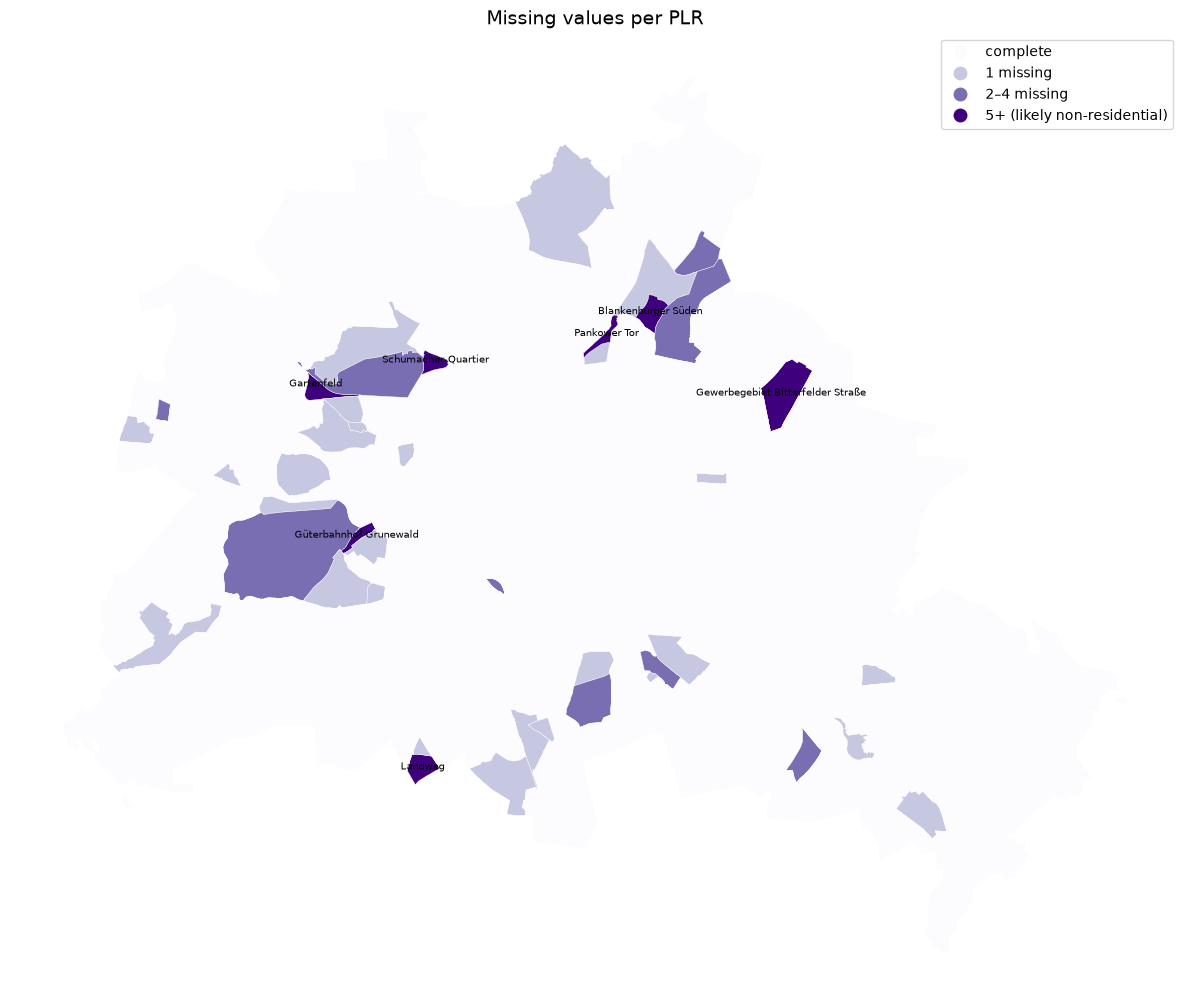

In [31]:
# 1. recompute n_missing + the zero-padded join k
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]
df["n_missing"] = df[feature_cols].isna().sum(axis=1)
#df["plr_key"] = df["plr_id"].astype(str).str.zfill(8)

# 3. join the counts onto the geometries
gdf = plr.merge(
    df.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id", "n_missing"]],
    on="plr_id", how="left"
)

# 4. bin — raw counts are dominated by the two 28s, so categories read better
bins   = [-1, 0, 1, 4, np.inf]
labels = ["complete", "1 missing", "2–4 missing", "5+ (likely non-residential)"]
gdf["missing_cat"] = pd.cut(gdf["n_missing"].fillna(0), bins=bins, labels=labels)

# 5. plot
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(column="missing_cat", categorical=True, legend=True,
         cmap="Purples", edgecolor="white", linewidth=0.3, ax=ax,
         missing_kwds={"color": "lightgrey", "label": "no geometry match"})
ax.set_title("Missing values per PLR", fontsize=14)
ax.axis("off")

# label the worst offenders
for _, r in gdf[gdf["n_missing"] >= 5].iterrows():
    c = r.geometry.representative_point()
    ax.annotate(r["plr_name"], (c.x, c.y), fontsize=7, ha="center")

plt.tight_layout()
plt.show()